In [1]:
import numpy as np
import matplotlib.pyplot as plt
from utils import deserialize_circuits
from qiskit import qpy
from qiskit.quantum_info import Operator
from tqdm.notebook import trange

In [ ]:
# def calc_distance(target,qc):
#     generated = Operator(qc).to_matrix()
#     return np.linalg.norm(target-generated)**2/2

import numpy as np
from qiskit.quantum_info import Operator

def _to_unitary(obj):
    """Accepts np.ndarray / Operator / QuantumCircuit and returns a complex128 matrix."""
    if isinstance(obj, np.ndarray):
        U = obj
    else:
        U = Operator(obj).data
    return np.asarray(U, dtype=np.complex128)

def calc_process_fidelity(target, qc):
    """
    Phase-free process fidelity between target unitary and the circuit's unitary:
        F_pro = |Tr(U_target^† U_generated)|^2 / d^2   ∈ [0, 1]
    Invariant to global phase differences.
    """
    U_t = _to_unitary(target)
    U_g = _to_unitary(qc)

    if U_t.shape != U_g.shape:
        raise ValueError(f"Dimension mismatch: {U_t.shape} vs {U_g.shape}")

    d = U_t.shape[0]
    s = np.trace(U_t.conj().T @ U_g)          # complex scalar
    F_pro = (np.abs(s)**2) / (d * d)
    return float(np.clip(F_pro.real, 0.0, 1.0))

def calc_pf_loss(target, qc):
    """Loss version: 1 - process fidelity  (smaller is better)."""
    return 1.0 - calc_process_fidelity(target, qc)

def calc_distance(target, qc):
    return calc_pf_loss(target, qc)


In [3]:
with open("d_diff_param.txt") as f:
    d_diff = np.array([float(line.strip()) for line in f if line.strip()])

# with open("distance_param.txt") as f:
#     d_no_es_list, *rest = zip(*[map(float, line.split()) for line in f if line.strip()])
# d_no_es = np.array(d_no_es_list)
# d_opt   = d_no_es - d_diff

with open("d_opt-917-best.txt") as f:
    d_no_es, d_opt = zip(*[map(float, line.split()) for line in f if line.strip()])

In [ ]:
# with open("distance_param.txt") as f:
#     d_no_es_list, *rest = zip(*[map(float, line.split()) for line in f if line.strip()])
# d_no_es = np.array(d_no_es_list)

In [ ]:
targets = np.load("targets_param.npy")

best_r_list = []

for i in trange(len(targets)):
    idx = i
    target = targets[idx]
    with open(f"random/{idx}.qpy", "rb") as f:
        random_circuits = qpy.load(f)

    r_dist = np.array([calc_distance(target, qc) for qc in random_circuits])
    # m_dist = np.array([calc_distance(target, qc) for qc in m_param_circuits])
    best_r = r_dist.min()
    best_r_list.append(best_r)



# plt.figure(figsize=(8,5))
# # Random circuits
# plt.hist(best_r_list, bins=100, alpha=0.4, label='Random Circuits', color='gray', edgecolor='black')

# # Before optimization
# plt.hist(d_no_es, bins=100, density=False, alpha=0.4,
#             label='Before Optimization', color='tab:blue', edgecolor='black')

# # After optimization
# # plt.hist(d_opt, bins=100, density=False, alpha=0.4,
# #          label='After Optimization', color='tab:orange', edgecolor='black')

# plt.xlabel("Distance", fontsize=12)
# plt.ylabel("Frequency", fontsize=12)
# plt.title(f"Distance Distribution for Target {idx}", fontsize=14)
# plt.legend(frameon=False, fontsize=11)
# plt.grid(axis='y', linestyle=':', alpha=0.7)
# plt.tight_layout()
# plt.show()

In [4]:
# np.savetxt("best_r_list.txt", best_r_list)
best_r_list = np.loadtxt("best_r_list.txt").tolist()

print("Loaded", len(best_r_list), "entries")

Loaded 10000 entries


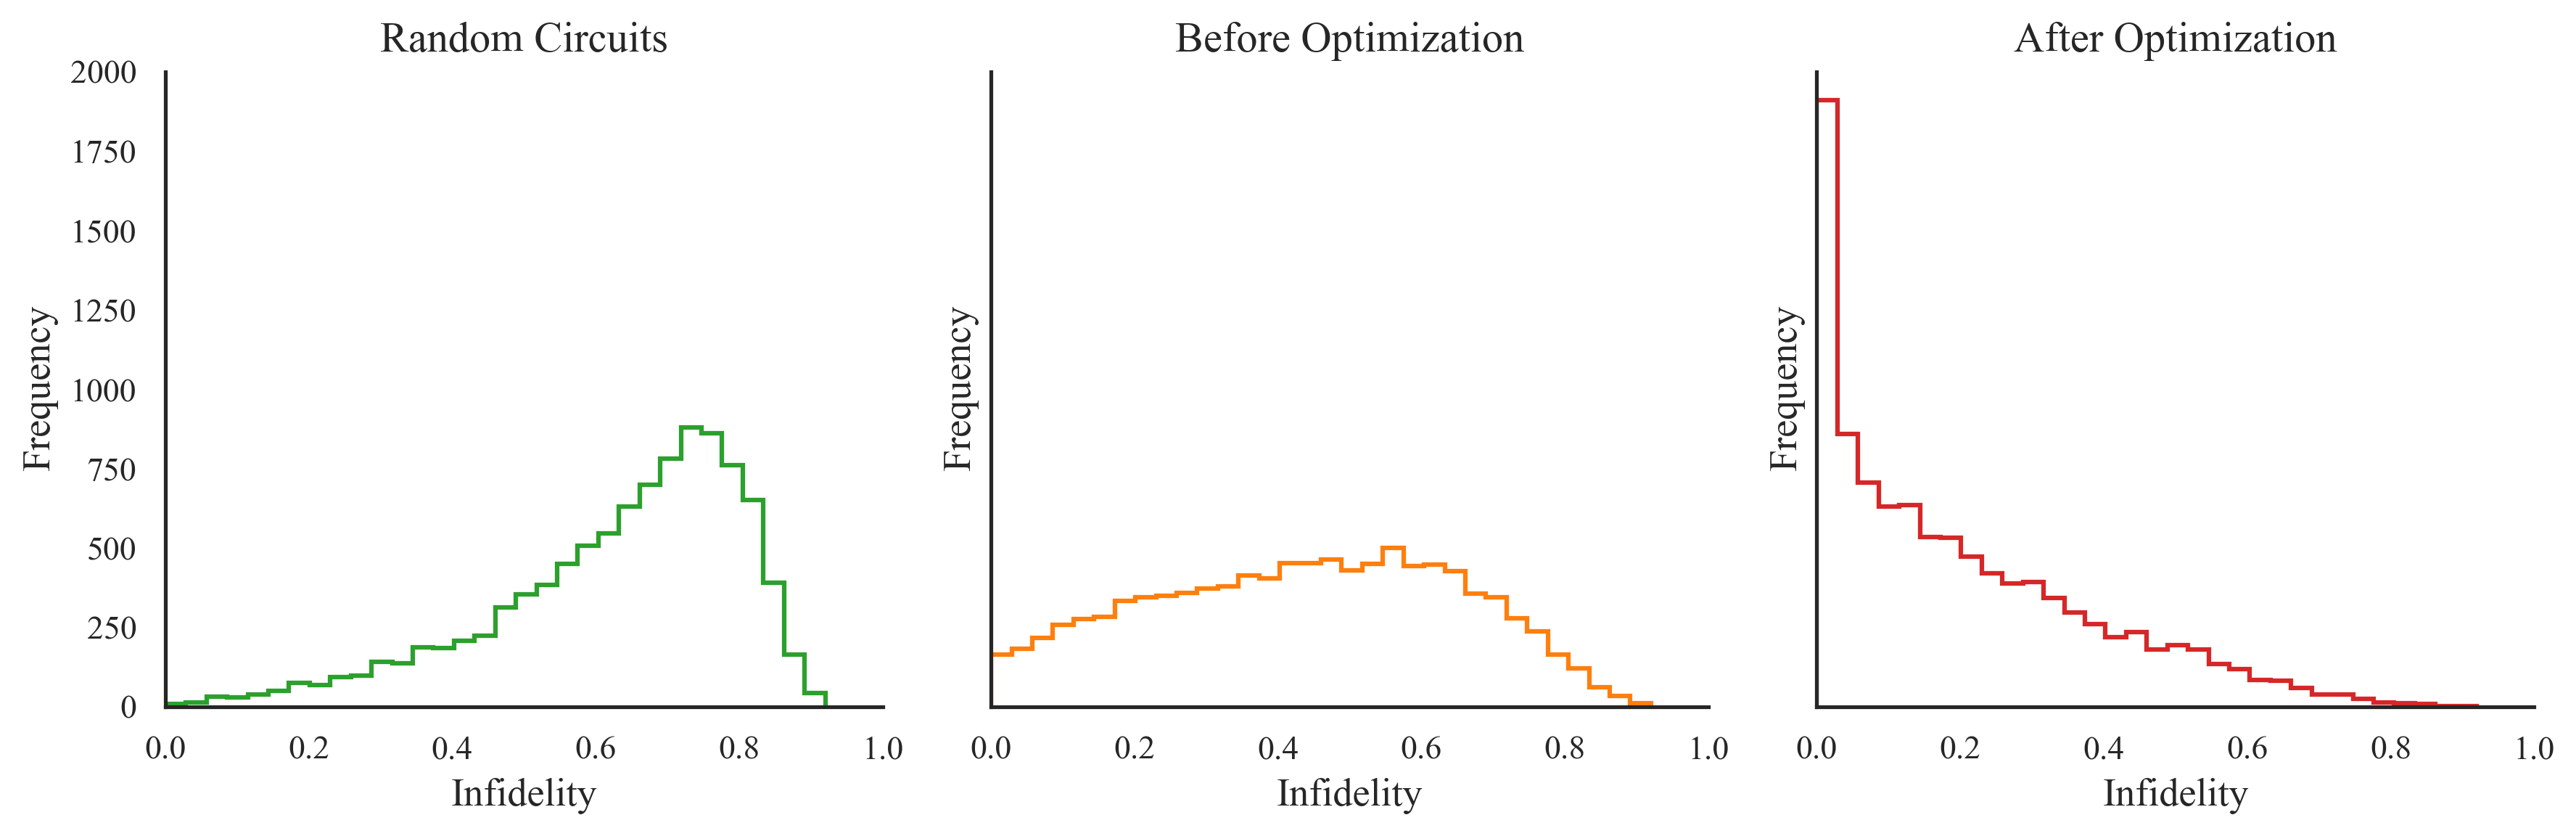

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


random   = np.array(best_r_list)
before_opt      = np.array(d_no_es)
after_opt = np.array(d_opt)

datasets = {
    'Random Circuits':         {'data': random,    'color': 'tab:green'},
    'Before Optimization':           {'data': before_opt,       'color': 'tab:orange'},
    'After Optimization': {'data': after_opt,  'color': 'tab:red'},
}

sns.set_theme(
    style='white',
    font='Times New Roman',
    rc={
        'figure.dpi': 300,
        'figure.figsize': (12, 4),
        'font.size': 12,
        'axes.titlesize': 14,
        'axes.labelsize': 13,
    }
)

all_data = np.concatenate([v['data'] for v in datasets.values()])
bins = np.histogram_bin_edges(all_data, bins='fd')

fig, axes = plt.subplots(1, 3, sharex=True, sharey=True)

for ax, (label, info) in zip(axes, datasets.items()):
    data = info['data']
    color = info['color']

    counts, edges = np.histogram(data, bins=bins)
    # ax.fill_between(
    #     edges[:-1],
    #     counts,
    #     step='post',
    #     color=color,
    #     alpha=0.3
    # )


    ax.hist(
        data,
        bins=bins,
        histtype='step',
        linewidth=1.5,
        color=color
    )

    ax.set_title(label)
    ax.set_xlabel("Infidelity")
    ax.set_ylabel("Frequency")

    ax.grid(False)
    ax.set_xlim(0, 1)

sns.despine(trim=True)

plt.tight_layout()
plt.show()


In [18]:
threshold = 1e-3

X = np.mean(after_opt  < threshold) * 100
Y = np.mean(before_opt < threshold) * 100

print(X, Y)

7.13 0.05


In [62]:
len(random)

10000

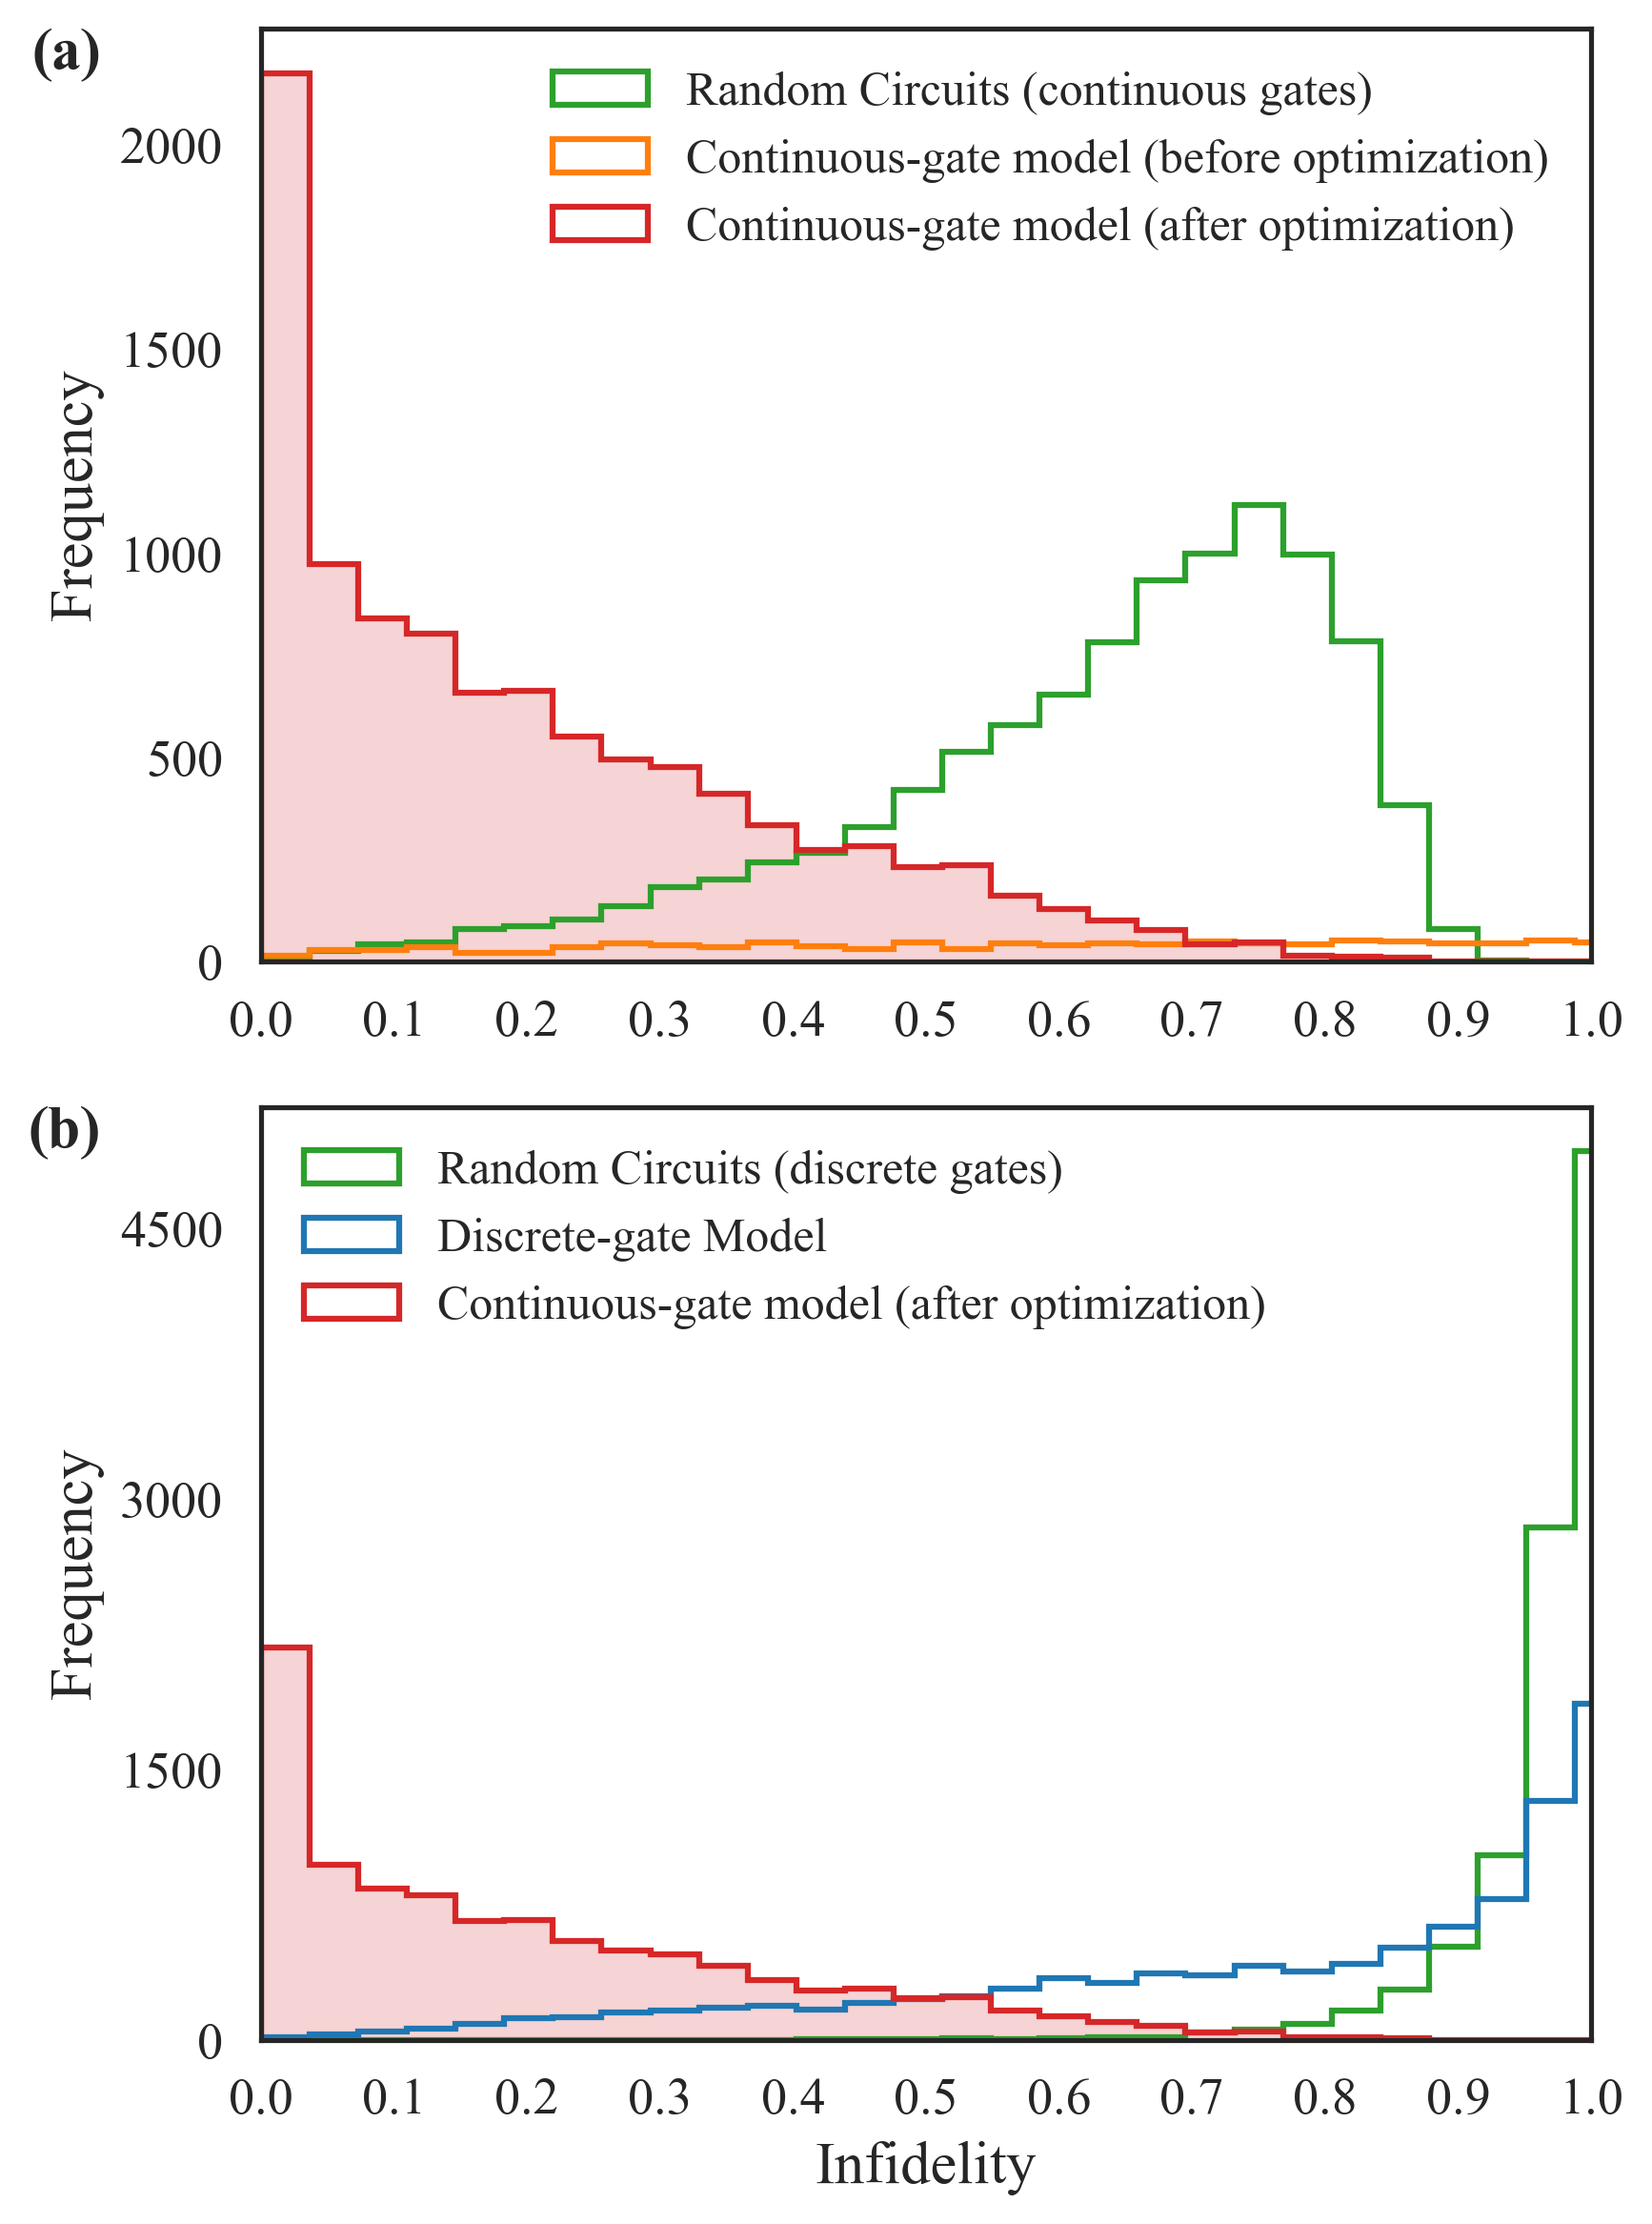

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MultipleLocator
from matplotlib.ticker import MaxNLocator

random     = np.array(best_r_list)
before_opt = np.array(d_no_es)
after_opt  = np.array(d_opt)

datasets1 = {
    'Random Circuits (continuous gates)':     {'data': random,      'color': 'tab:green'},
    'Continuous-gate model (before optimization)': {'data': before_opt,  'color': 'tab:orange'},
    'Continuous-gate model (after optimization)':  {'data': after_opt,   'color': 'tab:red'},
}

d_opt        = np.array(d_opt)  # After Optimization
fixed_dist   = np.loadtxt("distance_fixed-920.txt")      
fixed_random = np.loadtxt("distance_random_fixed2.txt")

datasets2 = {
    'Random Circuits (discrete gates)':               {'data': fixed_random, 'color': 'tab:green'},
    'Discrete-gate Model':  {'data': fixed_dist,   'color': 'tab:blue'},
    'Continuous-gate model (after optimization)': {'data': d_opt,        'color': 'tab:red'},
}

# ===== 全局样式 =====
sns.set_theme(
    style='white',
    font='Times New Roman',
    rc={
        'figure.dpi': 300,
        'font.size': 14,
        'axes.titlesize': 16,
        'axes.labelsize': 16,
        'xtick.labelsize': 13,
        'ytick.labelsize': 13,
        'legend.fontsize': 16,
    }
)
fig, axes = plt.subplots(2, 1, figsize=(6, 8))

d_diff = np.array(d_no_es) - np.array(d_opt)

# axes[0].hist(
#     d_diff,
#     bins='fd',
#     density=False,
#     alpha=0.6,
#     edgecolor='black',
#     label=r'Histogram of $d-d^\prime$'
# )

# axes[0].set_xlabel(r"$\Delta_{\mathrm{pf}} - \Delta_{\mathrm{pf}}'$", fontsize=12)
# axes[0].set_ylabel("Frequency", fontsize=12)
# # axes[0].set_title("(a) Optimization Effect Distribution")
# axes[0].xaxis.set_major_locator(MultipleLocator(0.1))
# # axes[0].legend(frameon=False)

# axes[0].text(
#     -0.12, 1, "(a)", transform=axes[0].transAxes,
#     fontsize=13, fontweight="bold", va="top", ha="right"
# )

all_data1 = np.concatenate([v['data'] for v in datasets1.values()])
bins1     = np.histogram_bin_edges(all_data1, bins='fd')
common_bins = np.histogram_bin_edges(
    np.concatenate([after_opt, d_opt, before_opt, random, fixed_dist, fixed_random]),
    bins='fd'
)

for label, info in datasets1.items():
    axes[0].hist(
        info['data'],
        bins=common_bins,
        histtype='step',
        linewidth=1.5,
        color=info['color'],
        label=label
    )

    if info['color'] == 'tab:red':
        axes[0].hist(
            after_opt,
            bins=common_bins,
            histtype='stepfilled',
            alpha=0.2,
            color='tab:red'
        )

axes[0].set_ylabel("Frequency", fontsize=15)
# axes[0].set_xlabel("Infidelity", fontsize=12)
axes[0].set_xlim(0, 1)
axes[0].xaxis.set_major_locator(MultipleLocator(0.1))
axes[0].yaxis.set_major_locator(MaxNLocator(nbins=5))
# axes[1].set_title("(b) Optimization Effect", fontsize=14)

axes[0].text(
    -0.12, 1, "(a)", transform=axes[0].transAxes,
    fontsize=15, fontweight="bold", va="top", ha="right"
)


axes[0].legend(
    frameon=False,
    fontsize=12,
    loc='upper right',
    # bbox_to_anchor=(1.02, 1.0) 
)

all_data2 = np.concatenate([v['data'] for v in datasets2.values()])
bins2     = np.histogram_bin_edges(all_data2, bins='fd')

for label, info in datasets2.items():
    axes[1].hist(
        info['data'],
        bins=common_bins,
        histtype='step',
        linewidth=1.5,
        color=info['color'],
        label=label
    )

    if info['color'] == 'tab:red':
        axes[1].hist(
            after_opt,
            bins=common_bins,
            histtype='stepfilled',
            alpha=0.2,
            color='tab:red'
        )

axes[1].set_xlabel("Infidelity", fontsize=15)
axes[1].set_ylabel("Frequency", fontsize=15)
axes[1].set_xlim(0, 1)
axes[1].xaxis.set_major_locator(MultipleLocator(0.1))
axes[1].yaxis.set_major_locator(MaxNLocator(nbins=5))
# axes[1].set_title("(c) Model Comparison", fontsize=14)
axes[1].text(
    -0.12, 1, "(b)", transform=axes[1].transAxes,
    fontsize=15, fontweight="bold", va="top", ha="right"
)

axes[1].legend(
    frameon=False,
    fontsize=12,
    loc='upper left',
    # bbox_to_anchor=(1.02, 1.0)
)

plt.tight_layout()
plt.savefig("output-comb-2.png", dpi=300, bbox_inches='tight', pad_inches=0.7)
# fig.subplots_adjust(right=0.9)
plt.show()


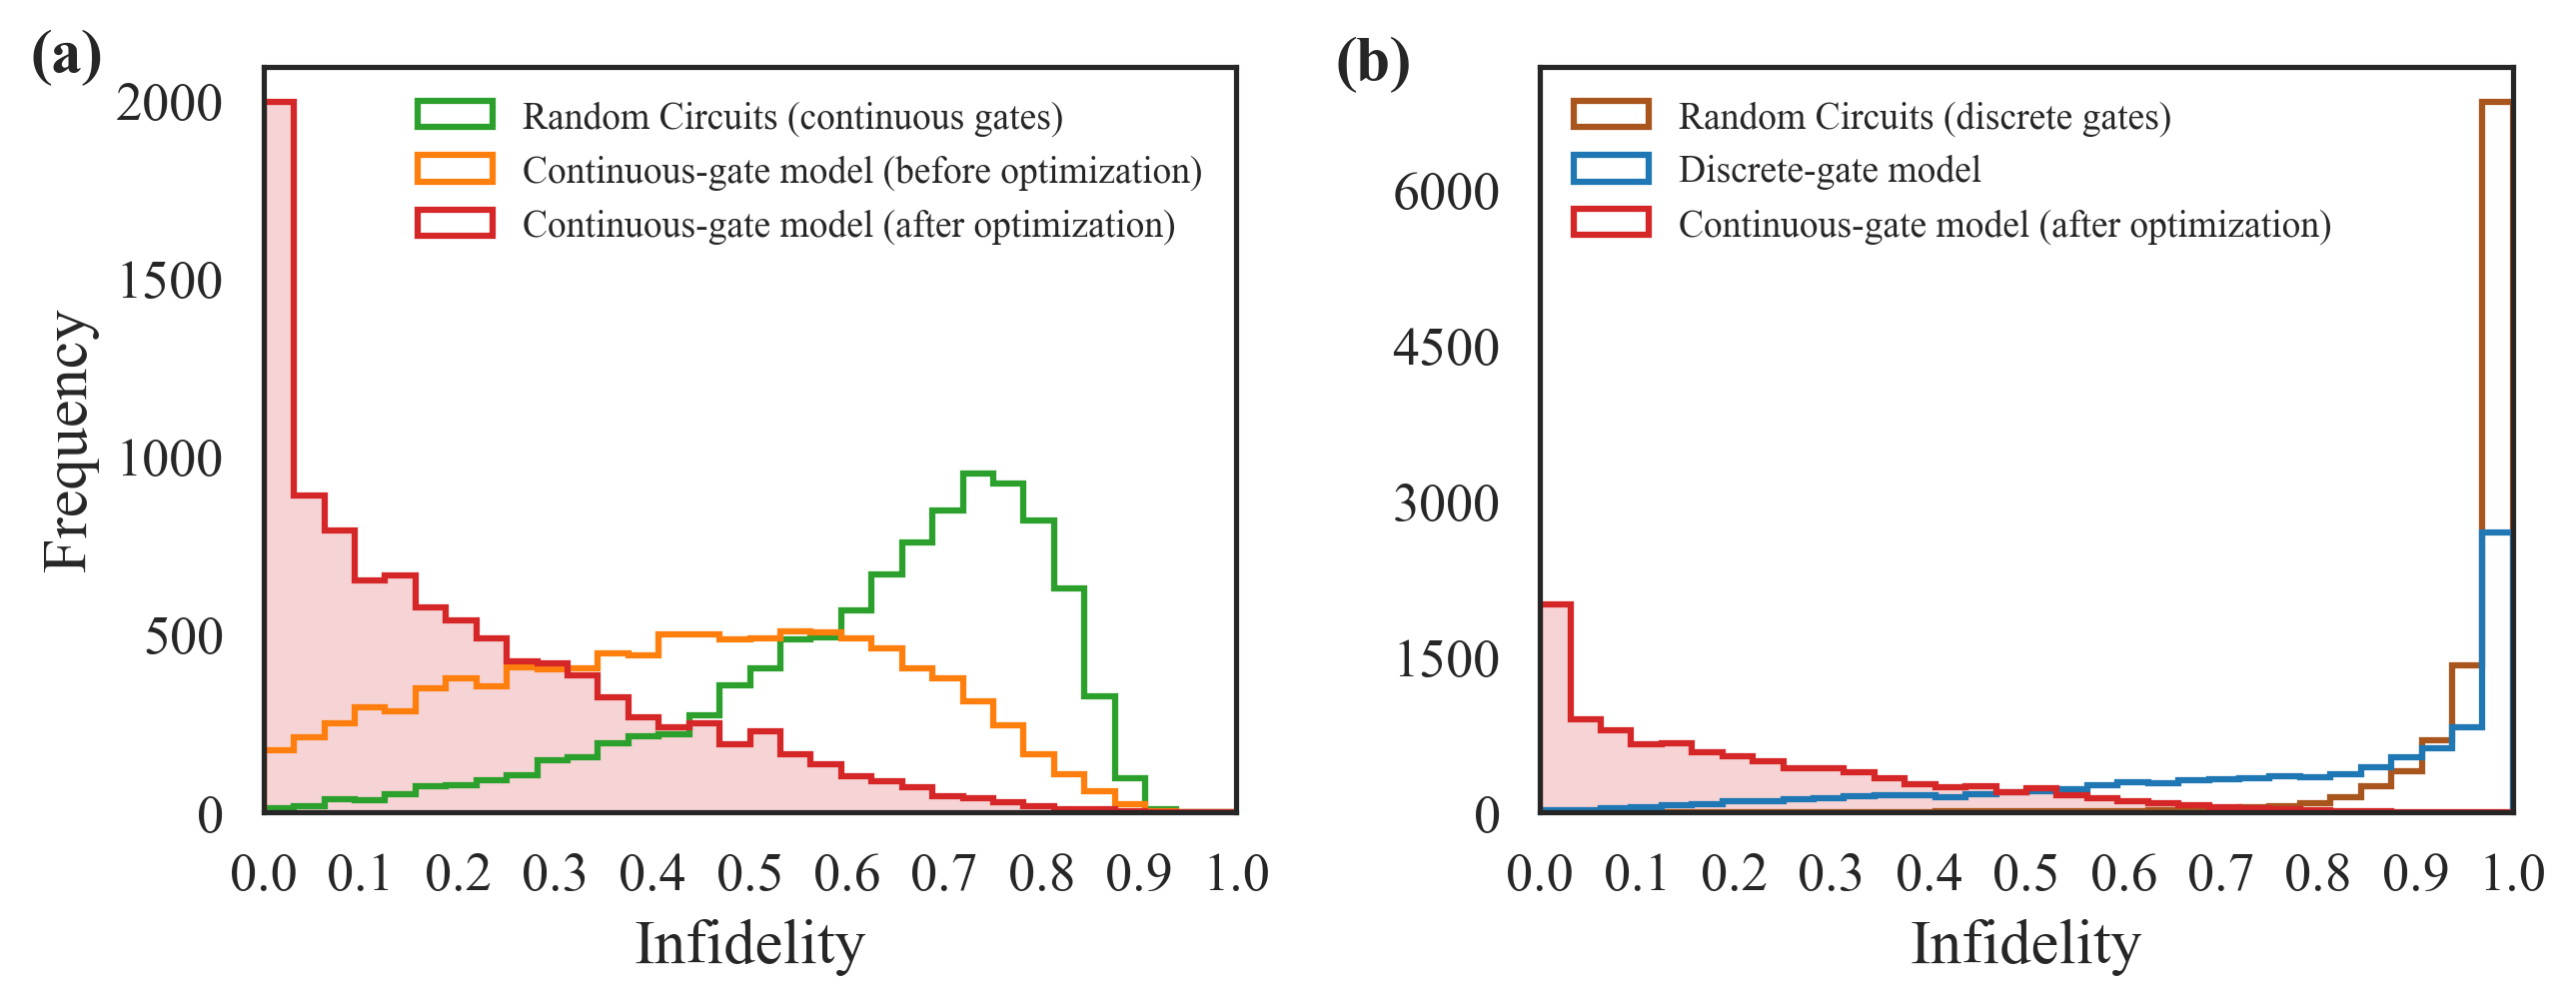

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MultipleLocator, MaxNLocator

random     = np.array(best_r_list)
before_opt = np.array(d_no_es)
after_opt  = np.array(d_opt)

datasets1 = {
    'Random Circuits (continuous gates)': {
        'data': random,
        'color': 'tab:green'
    },
    'Continuous-gate model (before optimization)': {
        'data': before_opt,
        'color': 'tab:orange'
    },
    'Continuous-gate model (after optimization)': {
        'data': after_opt,
        'color': 'tab:red'
    },
}

fixed_dist   = np.loadtxt("distance_fixed-920.txt")
fixed_random = np.loadtxt("distance_random_fixed2.txt")

datasets2 = {
    'Random Circuits (discrete gates)': {
        'data': fixed_random,
        'color': '#A9561E'
    },
    'Discrete-gate model': {
        'data': fixed_dist,
        'color': 'tab:blue'
    },
    'Continuous-gate model (after optimization)': {
        'data': after_opt,
        'color': 'tab:red'
    },
}

common_bins = np.histogram_bin_edges(
    np.concatenate([after_opt, before_opt, random,
                    fixed_dist, fixed_random]),
    bins='fd'
)

sns.set_theme(
    style='white',
    font='Times New Roman',
    rc={
        'figure.dpi': 300,
        'font.size': 14,
        'axes.labelsize': 15,
        'xtick.labelsize': 13,
        'ytick.labelsize': 13,
    }
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3.8))

for label, info in datasets1.items():
    ax1.hist(
        info['data'],
        bins=common_bins,
        histtype='step',
        linewidth=1.5,
        color=info['color'],
        label=label
    )

ax1.hist(
    after_opt,
    bins=common_bins,
    histtype='stepfilled',
    alpha=0.2,
    color='tab:red'
)

ax1.set_xlabel("Infidelity")
ax1.set_ylabel("Frequency")
ax1.set_xlim(0, 1)
ax1.xaxis.set_major_locator(MultipleLocator(0.1))
ax1.yaxis.set_major_locator(MaxNLocator(nbins=5))

ax1.text(
    -0.24, 1.05, "(a)",
    transform=ax1.transAxes,
    fontsize=15,
    fontweight="bold",
    ha="left",
    va="top"
)

ax1.legend(
    frameon=False,
    fontsize=9,
    loc='upper right'
)

for label, info in datasets2.items():
    ax2.hist(
        info['data'],
        bins=common_bins,
        histtype='step',
        linewidth=1.5,
        color=info['color'],
        label=label
    )

ax2.hist(
    after_opt,
    bins=common_bins,
    histtype='stepfilled',
    alpha=0.2,
    color='tab:red'
)

ax2.set_xlabel("Infidelity")
ax2.set_ylabel("") 
ax2.set_xlim(0, 1)
ax2.xaxis.set_major_locator(MultipleLocator(0.1))
ax2.yaxis.set_major_locator(MaxNLocator(nbins=5))

ax2.text(
    -0.21, 1.04, "(b)",
    transform=ax2.transAxes,
    fontsize=15,
    fontweight="bold",
    ha="left",
    va="top"
)

ax2.legend(
    frameon=False,
    fontsize=9,
    loc='upper left'
)


for ax in (ax1, ax2):
    ax.tick_params(labelsize=13)

# plt.tight_layout()
# plt.savefig("output-horizontal-clean.png",
#             dpi=300, bbox_inches='tight', pad_inches=0.8)
plt.tight_layout(pad=1.6, w_pad=1.2)
plt.savefig("output-horizontal-clean.png",
            dpi=300, bbox_inches='tight', pad_inches=1.3)
plt.show()
